In [3]:
# Import TensorFlow and Keras tools for deep learning
import tensorflow as tf
from tensorflow.keras import layers, models

# Import the pretrained MobileNetV2 architecture
from tensorflow.keras.applications import MobileNetV2

# Import plotting library for training graphs
import matplotlib.pyplot as plt

# Path helps us work with dataset folder paths cleanly
from pathlib import Path

In [4]:
train_dir = Path("../data/Training")
test_dir = Path("../data/Testing")

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
SEED = 42
EPOCHS = 10

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

Found 5524 files belonging to 4 classes.
Using 4420 files for training.
Found 5524 files belonging to 4 classes.
Using 1104 files for validation.
Found 554 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [7]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers first
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


553/553 ━━━━━━━━━━━━━━━━━━━━ 35s 60ms/step - accuracy: 0.5498 - loss: 1.0795 - val_accuracy: 0.7763 - val_loss: 0.6482
Epoch 2/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 32s 57ms/step - accuracy: 0.7457 - loss: 0.6602 - val_accuracy: 0.8243 - val_loss: 0.5078
Epoch 3/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 36s 66ms/step - accuracy: 0.7975 - loss: 0.5395 - val_accuracy: 0.8406 - val_loss: 0.4414
Epoch 4/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.8192 - loss: 0.4810 - val_accuracy: 0.8514 - val_loss: 0.4031
Epoch 5/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 34s 62ms/step - accuracy: 0.8351 - loss: 0.4351 - val_accuracy: 0.8560 - val_loss: 0.3745
Epoch 6/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - accuracy: 0.8489 - loss: 0.4049 - val_accuracy: 0.8741 - val_loss: 0.3527
Epoch 7/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 35s 64ms/step - accuracy: 0.8584 - loss: 0.3856 - val_accuracy: 0.8750 - val_loss: 0.3320
Epoch 8/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 39s 71ms/step - accuracy: 0.8622 - loss: 0.3614 - val_accurac

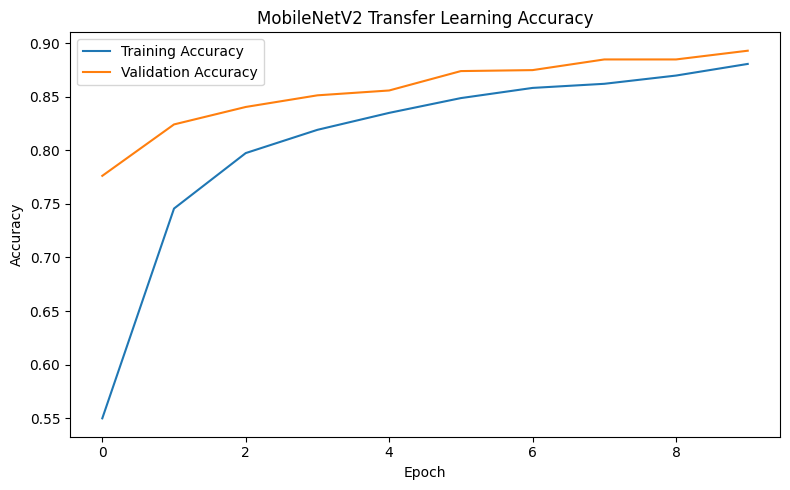

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("MobileNetV2 Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("../figures/mobilenet_accuracy.png", dpi=300)
plt.show()

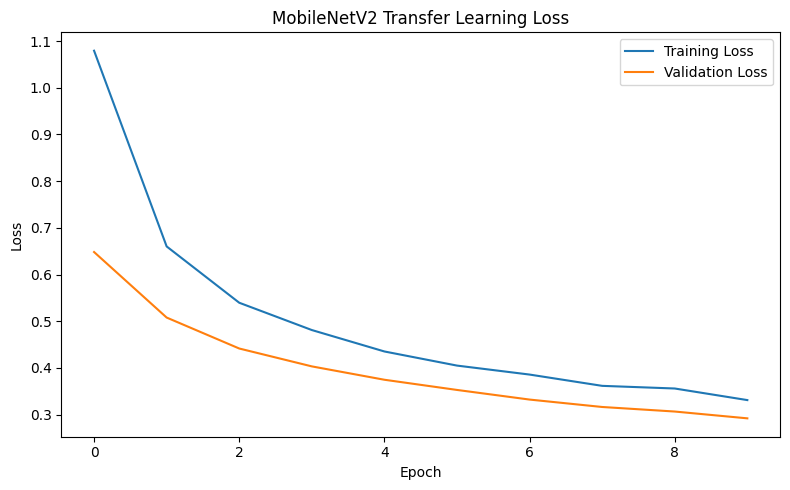

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("MobileNetV2 Transfer Learning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("../figures/mobilenet_loss.png", dpi=300)
plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("MobileNetV2 Test Loss:", test_loss)
print("MobileNetV2 Test Accuracy:", test_accuracy)

70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8736 - loss: 0.3905
MobileNetV2 Test Loss: 0.3905245065689087
MobileNetV2 Test Accuracy: 0.8736461997032166


In [16]:
model.save("../models/mobilenetv2_model.keras")

## MobileNetV2 Transfer Learning Summary

This notebook trained a MobileNetV2 transfer learning model for multiclass brain MRI tumor classification. The pretrained MobileNetV2 base was frozen and used as a feature extractor, while a new classification head was trained for the four MRI classes. This model will be compared against the baseline CNN to evaluate whether pretrained image representations improve classification performance.
